<font color='red' size='6'>REMINDER</font>

# Fill in any place that says `YOUR CODE HERE`.
- You should remove the line that says `raise NotImplementedError()`. If you do not, your code will (unsurprisingly) throw a run-time error and cause everything to fail.
- Do **NOT** write your answer anywhere else other than where it says `YOUR CODE HERE`. Simply write your code directly below this comment in the **same code cell**.

# Make sure everything runs as expected.
- Go to the menubar, select *Kernel* > *Restart & Run All*

# Do <ins>NOT</ins> change the title (i.e., file name) of this notebook.

# Do <ins>NOT</ins> delete any of the cells in this notebook.

# Make sure you save your work
- Go to the menubar, select *File* > *Save and Checkpoint*

In [1]:
# Run this code cell
from nose.tools import assert_equal, assert_in, assert_is_instance
from nose.tools import assert_almost_equal, assert_not_equal, assert_not_in

# 1. Historical Requests

Pallet Movers has given you a representative sample of requests for freight hauling services from customers during the years 2020 through 2022. The data is in the file `requests_3yr.csv` in the folder `data`. There is an additional column in comparison to some of the other data files you have seen from Pallet Movers before: `request_pickup_date`. This is the date that the customer would like for their freight to be picked up at the origin location. Read the data into a `DataFrame` variable named `requests`, being sure that the column `request_pickup_date` comes in as a date object.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

requests = pd.read_csv('./data/requests_3yr.csv',
                  parse_dates=['request_pickup_date'])
requests.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12128 entries, 0 to 12127
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   request_id                    12128 non-null  object        
 1   request_pickup_date           12128 non-null  datetime64[ns]
 2   origin_city                   12128 non-null  object        
 3   origin_state                  12128 non-null  object        
 4   origin_liftgate_service       12128 non-null  int64         
 5   destination_city              12128 non-null  object        
 6   destination_state             12128 non-null  object        
 7   destination_liftgate_service  12128 non-null  int64         
 8   handling_unit                 12128 non-null  object        
 9   length                        12128 non-null  int64         
 10  width                         12128 non-null  int64         
 11  height                      

In [3]:
# This is a test cell
# If **NO** message is printed, it means that the tests passed
# One basic test to see if your code works
import numpy as np
assert_equal(requests.request_pickup_date.dtype.type, np.datetime64, msg='Your column request_pickup_date is not a date')

<hr>

# 2. Change the Index

Set the index for your `DataFrame` named `requests` to the column `request_pickup_date`.

In [4]:
requests.set_index('request_pickup_date', inplace=True)
requests.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12128 entries, 2020-02-25 to 2022-08-02
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   request_id                    12128 non-null  object
 1   origin_city                   12128 non-null  object
 2   origin_state                  12128 non-null  object
 3   origin_liftgate_service       12128 non-null  int64 
 4   destination_city              12128 non-null  object
 5   destination_state             12128 non-null  object
 6   destination_liftgate_service  12128 non-null  int64 
 7   handling_unit                 12128 non-null  object
 8   length                        12128 non-null  int64 
 9   width                         12128 non-null  int64 
 10  height                        12128 non-null  int64 
 11  weight                        12128 non-null  int64 
dtypes: int64(6), object(6)
memory usage: 1.2+ MB


<hr>

# 3. Plotting the Number of Requests

You want to create two different line plots for the number of requests. 

1. Create a line plot where the $x$-axis is the month of the requested pickup date and the $y$-axis is the number of requests for each month. Use circles for markers on your line plot. (Sanity Check: You should have 36 circles on your line plot, one for each month where you have data.)
2. Create a line plot where the $x$-axis is the quarter of the requested pickup date and the $y$-axis is the number of requests for each quarter. Use circles for markers on your line plot. (Sanity Check: You should have 12 circles on your line plot, one for each quarter across the three-year period.)

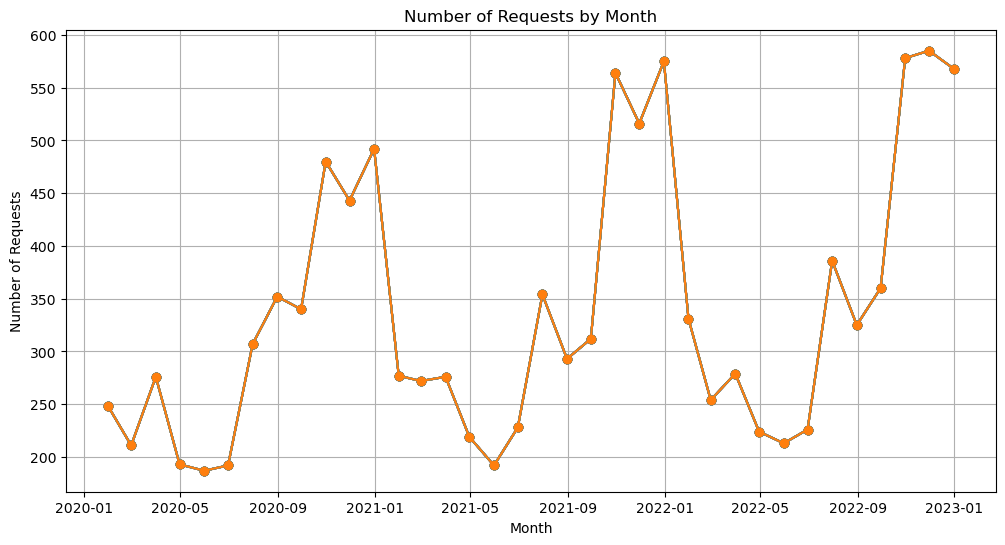

In [5]:
# 1. Monthly line plot
requests_per_month = requests.resample('M').count()

plt.figure(figsize=(12,6))
plt.plot(requests_per_month.index, requests_per_month.values, marker='o')
plt.xlabel('Month')
plt.ylabel('Number of Requests')
plt.title('Number of Requests by Month')
plt.grid(True)

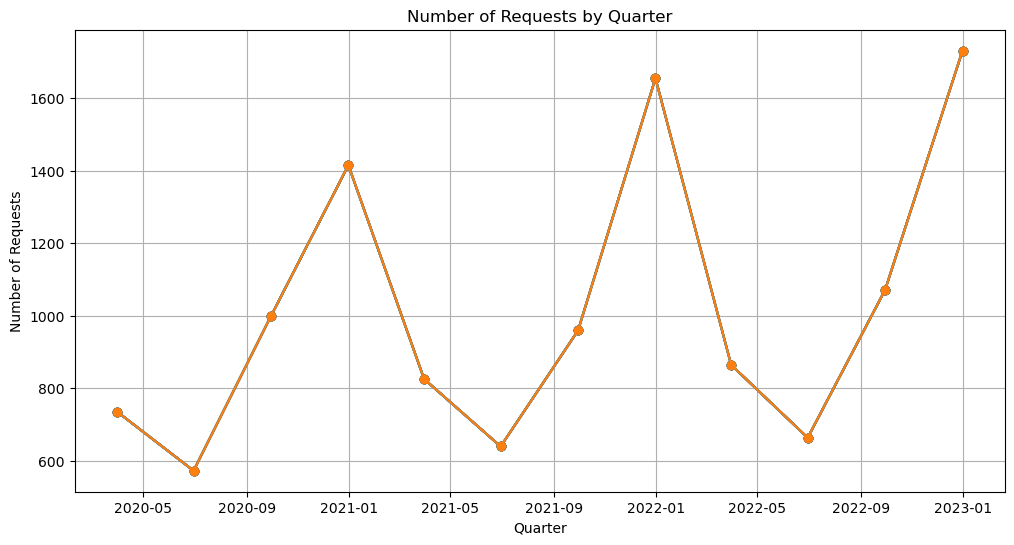

In [6]:
# 2. Quarterly line plot
requests_per_quarter = requests.resample('Q').count()

plt.figure(figsize=(12, 6))
plt.plot(requests_per_quarter.index, requests_per_quarter.values, marker='o')
plt.xlabel('Quarter')
plt.ylabel('Number of Requests')
plt.title('Number of Requests by Quarter')
plt.grid(True)

## Carefully explain any patterns and their insights that you see in the two line plots in the markdown cell below. 

For the monthly plot, we observe peaks between November and January across 2020-2023, followed by a steep decline. This pattern is captured in the quarterly plot as well, as we observe peaks each Q1, followed by subsquent decline, before rising again in Q4. This may be due to increased shipping demand around the holidays. 

# 4. Add Column

Add a column named `qtr` to the `requests` `DataFrame` to keep track of which quarter the requested pickup belongs to. If the request is in the first quarter (i.e., January, February, or March), the column `qtr` should contain the string "Q1". Similar coding should be done for the remaining quarters. 

In [7]:
# YOUR CODE HERE - lambda function for assigning quarters
requests['qtr'] = requests.index.quarter
requests['qtr'] = requests['qtr'].apply(lambda x: f"Q{x}")
requests.head()

,request_id,origin_city,origin_state,origin_liftgate_service,destination_city,destination_state,destination_liftgate_service,handling_unit,length,width,height,weight,qtr
request_pickup_date,,,,,,,,,,,,,
2020-02-25,2020_01_0001,Morgantown,WV,0,Birmingham,AL,0,box,36,36,24,362,Q1
2020-12-19,2020_01_0002,Birmingham,AL,0,White Plains,NY,0,pallet,48,40,60,3483,Q4
2020-09-12,2020_01_0003,Catskill,NY,0,White Plains,NY,0,pallet,48,40,54,4262,Q3
2020-04-24,2020_01_0004,Newport News,VA,0,White Plains,NY,0,pallet,48,40,42,3250,Q2
2020-05-19,2020_01_0005,Greensboro,NC,0,Catskill,NY,0,pallet,48,40,51,3834,Q2


In [8]:
# This is a test cell
# If **NO** message is printed, it means that the tests passed
# One basic test to see if your code works
assert_equal(requests.loc['2022-03-15']['qtr'][0], 'Q1', msg='You did not code quarter 1 correctly')

<hr>

<hr>

<hr>

# 5. Preparing Data for Modeling

Your end goal is to create a model that can predict the number of customer requests for the next four quarters for Pallet Movers. First, however, you must wrangle the data into a format conducive to creating a predictive model. Complete the following tasks to get the data into a suitable format. The image below shows what the resulting `DataFrame` should look like (note, the numbers may be different than shown). In particular, you **must use the column names as shown**. They are `year`, `request_id`, `origin_liftgate_service`, `destination_liftgate_service`, `length`, `width`, `height`, `weight`, `qtr_Q1`, `qtr_Q2`, `qtr_Q3`, and `tpi`.

![Format of data for modeling](images/data_format.png)

1. Add a column named `year` to the `requests` `DataFrame`.
2. Create a `DataFrame` named `summary_data` that groups by the year and the quarter, counts the number of requests, finds the average for `origin_liftgate_service`, `destination_liftgate_service`, `length`, `width`, and `height`, and finds the total `weight`. 
3. You need to get the parts of the MultiIndex in `summary_data` into their own columns. Store your results in a `DataFrame` named `qtrly_data`. 
4. Create dummy variables for `qtrly_data`, dropping the one created for the value 'Q4' in the column `qtr`. (Thought Exercise: Is there a reason Q4 is the one I want you to drop?) Store your results in a variable named `coded_data`. (**NOTE: Make sure the data type for each of the three columns is `int` by passing the argument `dtype=int` when creating the dummies.**)
5. Add a column named `tpi` to `coded_data`. This column represents the **time period index** and should start at 1 for the oldest quarter and count up by 1 for each additional quarter.


In [9]:
# 1. Add year to requests
requests['year'] = requests.index.year
requests.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12128 entries, 2020-02-25 to 2022-08-02
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   request_id                    12128 non-null  object
 1   origin_city                   12128 non-null  object
 2   origin_state                  12128 non-null  object
 3   origin_liftgate_service       12128 non-null  int64 
 4   destination_city              12128 non-null  object
 5   destination_state             12128 non-null  object
 6   destination_liftgate_service  12128 non-null  int64 
 7   handling_unit                 12128 non-null  object
 8   length                        12128 non-null  int64 
 9   width                         12128 non-null  int64 
 10  height                        12128 non-null  int64 
 11  weight                        12128 non-null  int64 
 12  qtr                           12128 non-null  object
 13 

In [10]:
# This is a test cell
# If **NO** message is printed, it means that the tests passed
# One basic test to see if your code works
assert_equal(requests.loc['2022-11-15']['year'][0], 2022, msg='You did not code the year for 2022-11-15 correctly')

<hr>

In [11]:
# 2. Create summary data
summary_data = requests.groupby(['year', 'qtr']).agg({
        'request_id': 'count',
        'origin_liftgate_service': 'mean',
        'destination_liftgate_service': 'mean',
        'length': 'mean',
        'width': 'mean',
        'height': 'mean',
        'weight': 'sum'
    })

In [12]:
# This is a test cell
# If **NO** message is printed, it means that the tests passed
# One basic test to see if your code works
assert_equal(type(summary_data.index), pd.MultiIndex, msg='Your summary_data does not have MultiIndex')

In [13]:
# This is a test cell
# If **NO** message is printed, it means that the tests passed
assert_equal(summary_data.shape[0], 12, msg='The shape of summary_data is incorrect')
assert_equal(summary_data.shape[1], 7, msg='The shape of summary_data is incorrect')

In [14]:
# 3. Create qtrly_data
qtrly_data = summary_data.reset_index()

#Move 'qtr' to end
pop = qtrly_data.pop('qtr')
qtrly_data['qtr'] = pop

#Check qtrly_data
qtrly_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   year                          12 non-null     int64  
 1   request_id                    12 non-null     int64  
 2   origin_liftgate_service       12 non-null     float64
 3   destination_liftgate_service  12 non-null     float64
 4   length                        12 non-null     float64
 5   width                         12 non-null     float64
 6   height                        12 non-null     float64
 7   weight                        12 non-null     int64  
 8   qtr                           12 non-null     object 
dtypes: float64(5), int64(3), object(1)
memory usage: 992.0+ bytes


In [15]:
# This is a test cell
# If **NO** message is printed, it means that the tests passed
# One basic test to see if your code works
assert_equal(qtrly_data.shape[0], 12, msg='The shape of qtrly_data is incorrect')

<hr>

In [16]:
# 4. Create dummies
#    Make sure the resulting data type for the three columns is `int`
#    by sending the argument `dtype=int` when creating the dummies
# Create dummies
coded_data = pd.get_dummies(qtrly_data, dtype=int)

#Drop 'qtr_Q4'
coded_data = coded_data.drop(columns='qtr_Q4')

#Check
coded_data.info()
coded_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   year                          12 non-null     int64  
 1   request_id                    12 non-null     int64  
 2   origin_liftgate_service       12 non-null     float64
 3   destination_liftgate_service  12 non-null     float64
 4   length                        12 non-null     float64
 5   width                         12 non-null     float64
 6   height                        12 non-null     float64
 7   weight                        12 non-null     int64  
 8   qtr_Q1                        12 non-null     int32  
 9   qtr_Q2                        12 non-null     int32  
 10  qtr_Q3                        12 non-null     int32  
dtypes: float64(5), int32(3), int64(3)
memory usage: 1.0 KB


,year,request_id,origin_liftgate_service,destination_liftgate_service,length,width,height,weight,qtr_Q1,qtr_Q2,qtr_Q3
0,2020,735,0.103401,0.225850,46.710204,41.888435,56.141497,2565008,1,0,0
1,2020,572,0.103147,0.227273,46.930070,42.230769,56.538462,2015011,0,1,0
2,2020,999,0.113113,0.242242,46.834835,42.166166,56.670671,3522716,0,0,1
3,2020,1415,0.124382,0.228269,46.736396,42.049470,56.128622,4945855,0,0,0
4,2021,825,0.126061,0.213333,46.894545,42.055758,56.549091,2917176,1,0,0


In [17]:
# This is a test cell
# If **NO** message is printed, it means that the tests passed
# One basic test to see if your code works
assert_not_in('qtr_Q4', coded_data.columns, msg='You still have qtr_Q4 in the columns of coded_data')

<hr>

In [18]:
# 5. Add time period index as column named tpi
coded_data['tpi'] = range(1, len(coded_data) + 1)
coded_data.head()

,year,request_id,origin_liftgate_service,destination_liftgate_service,length,width,height,weight,qtr_Q1,qtr_Q2,qtr_Q3,tpi
0,2020,735,0.103401,0.225850,46.710204,41.888435,56.141497,2565008,1,0,0,1
1,2020,572,0.103147,0.227273,46.930070,42.230769,56.538462,2015011,0,1,0,2
2,2020,999,0.113113,0.242242,46.834835,42.166166,56.670671,3522716,0,0,1,3
3,2020,1415,0.124382,0.228269,46.736396,42.049470,56.128622,4945855,0,0,0,4
4,2021,825,0.126061,0.213333,46.894545,42.055758,56.549091,2917176,1,0,0,5


In [19]:
# This is a test cell
# If **NO** message is printed, it means that the tests passed
# One basic test to see if your code works
assert_in('tpi', coded_data.columns, msg='You did not add the column tpi to coded_data')

<hr>

# 6. Build a Model

Using the `statsmodels` package, you want to fit a regression model on the entire dataset (remember, Pallet Movers gave you a sample for the purpose of proof-of-concept modeling). There are two "obvious" choices for your dependent variable: the number of requests for the quarter or the total weight of requests for the quarter. The number of requests and total weight are highly dependent upon each other. As such, you will not have either of them when making the prediction. 

After discussing this issue with Pallet Movers, you have decided to try to predict the number of requests, which should be column named `request_id` in your variable `coded_data`. You will start by using all of the other attributes in your `coded_data` **except `year` and `weight`** as the independent (i.e., $x$) variables. 

Create a variable named `full_mlr_results` that stores the results of the fitted ordinary least squares model from `statsmodels`.

In [20]:
### BEGIN SOLUTION
from statsmodels.formula.api import ols

X = coded_data.drop(columns=['request_id', 'year', 'weight'])
y = coded_data['request_id']

data_full = X.copy()
data_full['request_id'] = y

#create the right-hand side (rhs) of the formula with all X variables
rhs = '+'.join(X.columns)

#fit OLS model
full_mlr_results = ols('request_id ~'+rhs, data=data_full).fit()
print(full_mlr_results.summary())


                            OLS Regression Results                            
Dep. Variable:             request_id   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.942
Method:                 Least Squares   F-statistic:                     20.90
Date:                Tue, 16 Apr 2024   Prob (F-statistic):             0.0465
Time:                        19:33:09   Log-Likelihood:                -60.825
No. Observations:                  12   AIC:                             141.6
Df Residuals:                       2   BIC:                             146.5
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

C:\Users\danie\anaconda3\envs\BUAD512B\lib\site-packages\scipy\stats\_stats_py.py:1769: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=12
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [21]:
# This is a test cell
# If **NO** message is printed, it means that the tests passed
# One basic test to see if your code works
assert_in('full_mlr_results', dir(), msg='You did not name the variable `full_mlr_results` as instructed')

<hr>

# 7. Another Model

After examining the results of your full ordinary least squares model, you have decided to try another regression model with fewer variables. This time, fit an ordinary least squares model with only the time period index and the three dummy variables representing the quarters. Store your results in a variable named `mlr_results`. 

In [22]:
# YOUR CODE HERE
mlr_results = ols('request_id ~+qtr_Q1+qtr_Q2+qtr_Q3+tpi', data=data_full).fit()
print(mlr_results.summary())


                            OLS Regression Results                            
Dep. Variable:             request_id   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     104.3
Date:                Tue, 16 Apr 2024   Prob (F-statistic):           2.57e-06
Time:                        19:33:09   Log-Likelihood:                -63.525
No. Observations:                  12   AIC:                             137.0
Df Residuals:                       7   BIC:                             139.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1448.3333     57.578     25.154      0.0

C:\Users\danie\anaconda3\envs\BUAD512B\lib\site-packages\scipy\stats\_stats_py.py:1769: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=12
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [23]:
# This is a test cell
# If **NO** message is printed, it means that the tests passed
# One basic test to see if your code works
assert_in('mlr_results', dir(), msg='You did not name the variable `mlr_results` as instructed')

<hr>

# 8. Statistically Significant Variables

Create a `list` variable named `statistically_significant` and programmatically add the name of all the independent variables from your `mlr_results` that have a $p$-value < 0.05 to the list. Do **not** include the intercept in this list.

In [24]:
# YOUR CODE HERE
statistically_significant = []
pvalues = mlr_results.pvalues

def stat(pvalues):
    for index, value in pvalues.items():
        if index != 'Intercept' and value < .05:
            statistically_significant.append(index)
    return statistically_significant

stat(pvalues)
statistically_significant

['qtr_Q1', 'qtr_Q2', 'qtr_Q3', 'tpi']

<hr>

**&copy; 2022 - Present: Matthew D. Dean, Ph.D.   
Clinical Associate Professor of Business Analytics at William \& Mary.**